# Model Validation Notebook

Load a saved model from `data/saved_models/` and run validation.

In [1]:
import pandas as pd
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
from collections import Counter
from pathlib import Path

# Imports from our project
from src.utils.paths import PROJECT_ROOT, get_data_folder
from src.utils.ontology_utils import load_ontology
from src.train.model import SimpleNN
from src.train.loss import MarginalizationLoss

## 1. Select and Load Model

In [2]:
# List all available models
save_dir = PROJECT_ROOT / "data" / "saved_models"
model_files = sorted(glob.glob(str(save_dir / "blood_cell_model_*.pt")))

print("Available models:")
for i, model_file in enumerate(model_files):
    model_name = model_file.split('/')[-1]
    print(f"  [{i}] {model_name}")

if not model_files:
    print("\n⚠️  No saved models found in data/saved_models/")
    print("   Please train a model first using train_blood_cell.ipynb")
else:
    # Auto-select the latest model (or change index to select different model)
    model_index = -2  # -1 = latest, 0 = oldest, etc.
    model_path = model_files[model_index]
    print(f"\n✓ Selected: {model_path.split('/')[-1]}")

Available models:
  [0] blood_cell_model_2025-10-31_07-02-10.pt
  [1] blood_cell_model_2025-10-31_07-02-10_weights_only.pt
  [2] blood_cell_model_2025-11-01_00-10-25.pt
  [3] blood_cell_model_2025-11-01_00-10-25_weights_only.pt
  [4] blood_cell_model_2025-11-03_09-03-54.pt
  [5] blood_cell_model_2025-11-03_09-03-54_weights_only.pt

✓ Selected: blood_cell_model_2025-11-03_09-03-54.pt


In [3]:
# Load checkpoint
print(f"Loading checkpoint from: {model_path}")
checkpoint = torch.load(model_path, map_location='cpu')

# Print checkpoint info
print("\n" + "="*80)
print("CHECKPOINT INFORMATION")
print("="*80)
print(f"Model architecture: SimpleNN()")
print(f"Training epochs: {checkpoint['epoch']}")
print(f"Total batches processed: {checkpoint['total_batches_processed']:,}")
print(f"Final training loss: {checkpoint['batch_loss_history'][-1]:.4f}")
print(f"Trained on {checkpoint['num_gpus']} GPU(s)")
print(f"Total training time: {sum(checkpoint['epoch_times'])/3600:.2f} hours")
print("="*80 + "\n")

# Extract key variables
DATE = checkpoint['date_preprocessed']
input_dim = checkpoint['input_dim']
output_dim = checkpoint['output_dim']

Loading checkpoint from: /home/jingqiao/real_McCell/data/saved_models/blood_cell_model_2025-11-03_09-03-54.pt

CHECKPOINT INFORMATION
Model architecture: SimpleNN()
Training epochs: 3
Total batches processed: 58,995
Final training loss: 0.5783
Trained on 6 GPU(s)
Total training time: 8.36 hours



## 2. Load Preprocessed Data

In [4]:
# Load data from the same date as the model was trained on
PROCESSED_DATA_DIR = get_data_folder(DATE)
print(f"Loading data from: {PROCESSED_DATA_DIR} for date {DATE}")

# Load the ontology
cl = load_ontology()

# Load DataFrames
marginalization_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_marginalization_df.csv", index_col=0)
parent_child_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_parent_child_df.csv", index_col=0)
exclusion_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_exclusion_df.csv", index_col=0)

# Load mapping_dict
mapping_dict_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_mapping_dict_df.csv", index_col=0)
mapping_dict = pd.Series(mapping_dict_df.iloc[:, 0].values, index=mapping_dict_df.index).to_dict()

# Load leaf and internal values
with open(PROCESSED_DATA_DIR / f"{DATE}_leaf_values.pkl", "rb") as fp:
    leaf_values = pickle.load(fp)
with open(PROCESSED_DATA_DIR / f"{DATE}_internal_values.pkl", "rb") as fp:
    internal_values = pickle.load(fp)

print("\nAll data artifacts loaded successfully.")
print(f"Loaded {len(mapping_dict)} cell types.")
print(f"  - {len(leaf_values)} leaf nodes")
print(f"  - {len(internal_values)} internal nodes")

Loading data from: /home/jingqiao/real_McCell/data/processed/10-24 for date 2025-10-24
Loading cached ontology from /home/jingqiao/real_McCell/data/processed/ontology.pkl...
Ontology loaded successfully.

All data artifacts loaded successfully.
Loaded 80 cell types.
  - 23 leaf nodes
  - 57 internal nodes


## 3. Initialize Model and Load Weights

In [5]:
# Setup device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create model architecture
validation_model = SimpleNN(input_dim=input_dim, output_dim=output_dim)

# Handle DataParallel if model was trained on multiple GPUs
num_gpus = torch.cuda.device_count()
if num_gpus > 1:
    validation_model = torch.nn.DataParallel(validation_model)
    validation_model.module.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded DataParallel model ({num_gpus} GPUs available)")
else:
    validation_model.load_state_dict(checkpoint['model_state_dict'])
    print("Loaded model (single GPU)")

validation_model = validation_model.to(device)
validation_model.eval()

print("Model loaded successfully and set to evaluation mode.")

# Initialize loss function
loss_fn = MarginalizationLoss(
    marginalization_df=marginalization_df,
    parent_child_df=parent_child_df,
    exclusion_df=exclusion_df,
    leaf_values=leaf_values,
    internal_values=internal_values,
    mapping_dict=mapping_dict,
    device=device
)
print("Loss function initialized.")

Using device: cpu
Loaded model (single GPU)
Model loaded successfully and set to evaluation mode.
Loss function initialized.


## 4. Create Validation DataLoader

In [6]:
import cellxgene_census
import tiledbsoma as soma
from tiledbsoma_ml import ExperimentDataset, experiment_dataloader

# Get all cell types
all_cell_values = list(mapping_dict.keys())

# Load gene list from BioMart
print("Loading protein-coding genes from BioMart...")
biomart_path = PROJECT_ROOT / "hpc_workaround/data/mart_export.txt"
biomart = pd.read_csv(biomart_path)
coding_only = biomart[biomart['Gene type'] == 'protein_coding']
gene_list = coding_only['Gene stable ID'].tolist()
print(f"Loaded {len(gene_list)} protein-coding genes")

# Create filter strings
var_value_filter = f"feature_id in {gene_list}"
obs_value_filter = f'assay == "10x 3\' v3" and is_primary_data == True and cell_type_ontology_term_id in {all_cell_values}'

# Open SOMA database
soma_uri = "/scratch/sigbio_project_root/sigbio_project25/jingqiao/mccell-single/soma_db_homo_sapiens"
print(f"\nOpening local SOMA database at: {soma_uri}")
experiment = soma.open(soma_uri, mode="r")

# Create validation dataset
with experiment.axis_query(
    measurement_name="RNA",
    obs_query=soma.AxisQuery(value_filter=obs_value_filter),
    var_query=soma.AxisQuery(value_filter=var_value_filter),
) as query:
    experiment_dataset = ExperimentDataset(
        query,
        obs_column_names=["cell_type_ontology_term_id"],
        layer_name="raw",
        batch_size=256,
        shuffle=True,
        seed=999  # Different seed for validation
    )
    
    # Use only validation split (20%)
    _, val_dataset = experiment_dataset.random_split(0.8, 0.2, seed=42)
    
    print(f'\nValidation set size: {len(val_dataset)}')
    print(f'Validation dataset shape: {val_dataset.shape}')

val_dataloader = experiment_dataloader(val_dataset)
print("Validation dataloader ready.")

Loading protein-coding genes from BioMart...
Loaded 23262 protein-coding genes

Opening local SOMA database at: /scratch/sigbio_project_root/sigbio_project25/jingqiao/mccell-single/soma_db_homo_sapiens

Validation set size: 4917
Validation dataset shape: (4917, 20060)
Validation dataloader ready.


## 5. Run Validation (Leaf Nodes Only)

In [ ]:
print("="*80)
print("RUNNING VALIDATION (LEAF NODES ONLY)")
print("="*80)
print("Processing ENTIRE validation set (all batches)\n")

val_total_losses = []
val_leaf_losses = []
val_parent_losses = []
all_predictions = []
all_labels = []

leaf_indices_set = {mapping_dict[cid] for cid in leaf_values}
total_samples = 0
leaf_samples = 0

with torch.no_grad():
    for i, (X_batch, obs_batch) in enumerate(val_dataloader):
        # Data preparation
        X_batch = torch.from_numpy(X_batch).float()
        X_batch = torch.log1p(X_batch)
        X_batch = X_batch.to(device)

        label_strings = obs_batch["cell_type_ontology_term_id"]
        y_batch = torch.tensor([mapping_dict[term] for term in label_strings],
                              device=device, dtype=torch.long)

        total_samples += len(y_batch)

        # FILTER: Only keep samples with LEAF node labels
        is_leaf = torch.tensor([y.item() in leaf_indices_set for y in y_batch], device=device)

        if is_leaf.sum() == 0:
            continue  # Skip batches with no leaf samples

        X_batch_leaf = X_batch[is_leaf]
        y_batch_leaf = y_batch[is_leaf]
        leaf_samples += len(y_batch_leaf)

        # Forward pass
        outputs = validation_model(X_batch_leaf)
        total_loss, loss_leafs, loss_parents = loss_fn(outputs, y_batch_leaf)

        val_total_losses.append(total_loss.item())
        val_leaf_losses.append(loss_leafs.item())
        val_parent_losses.append(loss_parents.item())

        # Get predictions (argmax of logits)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch_leaf.cpu().numpy())

# Calculate metrics
avg_val_loss = np.mean(val_total_losses)
avg_leaf_loss = np.mean(val_leaf_losses)
avg_parent_loss = np.mean(val_parent_losses)

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
accuracy = (all_predictions == all_labels).mean()

print(f"\nValidation Results (LEAF-LABELED SAMPLES ONLY):")
print(f"  Total samples processed: {total_samples:,}")
print(f"  Leaf-labeled samples: {leaf_samples:,} ({leaf_samples/total_samples*100:.1f}%)")
print(f"  Internal-labeled samples (skipped): {total_samples - leaf_samples:,}")
print(f"\n  Average Total Loss: {avg_val_loss:.4f}")
print(f"  Average Leaf Loss:  {avg_leaf_loss:.4f}")
print(f"  Average Parent Loss: {avg_parent_loss:.4f}")
print(f"  Leaf Accuracy: {accuracy*100:.2f}%")
print("\n" + "="*80)

## 6. Per-Class Accuracy

In [8]:
# Create reverse mapping (index -> CL ID)
reverse_mapping = {v: k for k, v in mapping_dict.items()}

# Per-class accuracy
unique_labels = np.unique(all_labels)
per_class_accuracy = {}

print("\n" + "="*80)
print("PER-CLASS ACCURACY (LEAF NODES)")
print("="*80)
print(f"{'Cell Type':<50} {'Count':<8} {'Accuracy':<10}")
print("-" * 80)

for label_idx in sorted(unique_labels):
    mask = all_labels == label_idx
    class_acc = (all_predictions[mask] == label_idx).mean()
    count = mask.sum()
    
    cl_id = reverse_mapping[label_idx]
    cell_name = cl[cl_id].name
    per_class_accuracy[cl_id] = class_acc
    
    print(f"{cell_name:<50} {count:<8} {class_acc*100:>6.2f}%")

print("="*80 + "\n")


PER-CLASS ACCURACY (LEAF NODES)
Cell Type                                          Count    Accuracy  
--------------------------------------------------------------------------------
platelet                                           31       100.00%
naive thymus-derived CD4-positive, alpha-beta T cell 216       90.74%
naive thymus-derived CD8-positive, alpha-beta T cell 87        91.95%
central memory CD4-positive, alpha-beta T cell     107       90.65%
effector memory CD4-positive, alpha-beta T cell    62        67.74%
cytotoxic T cell                                   25        76.00%
helper T cell                                      72        95.83%
effector memory CD8-positive, alpha-beta T cell    55        94.55%
CD16-negative, CD56-bright natural killer cell, human 15        93.33%
CD16-positive, CD56-dim natural killer cell, human 49       100.00%
mucosal invariant T cell                           12        83.33%
IgA plasma cell                                    19       

## 7. Confusion Matrix

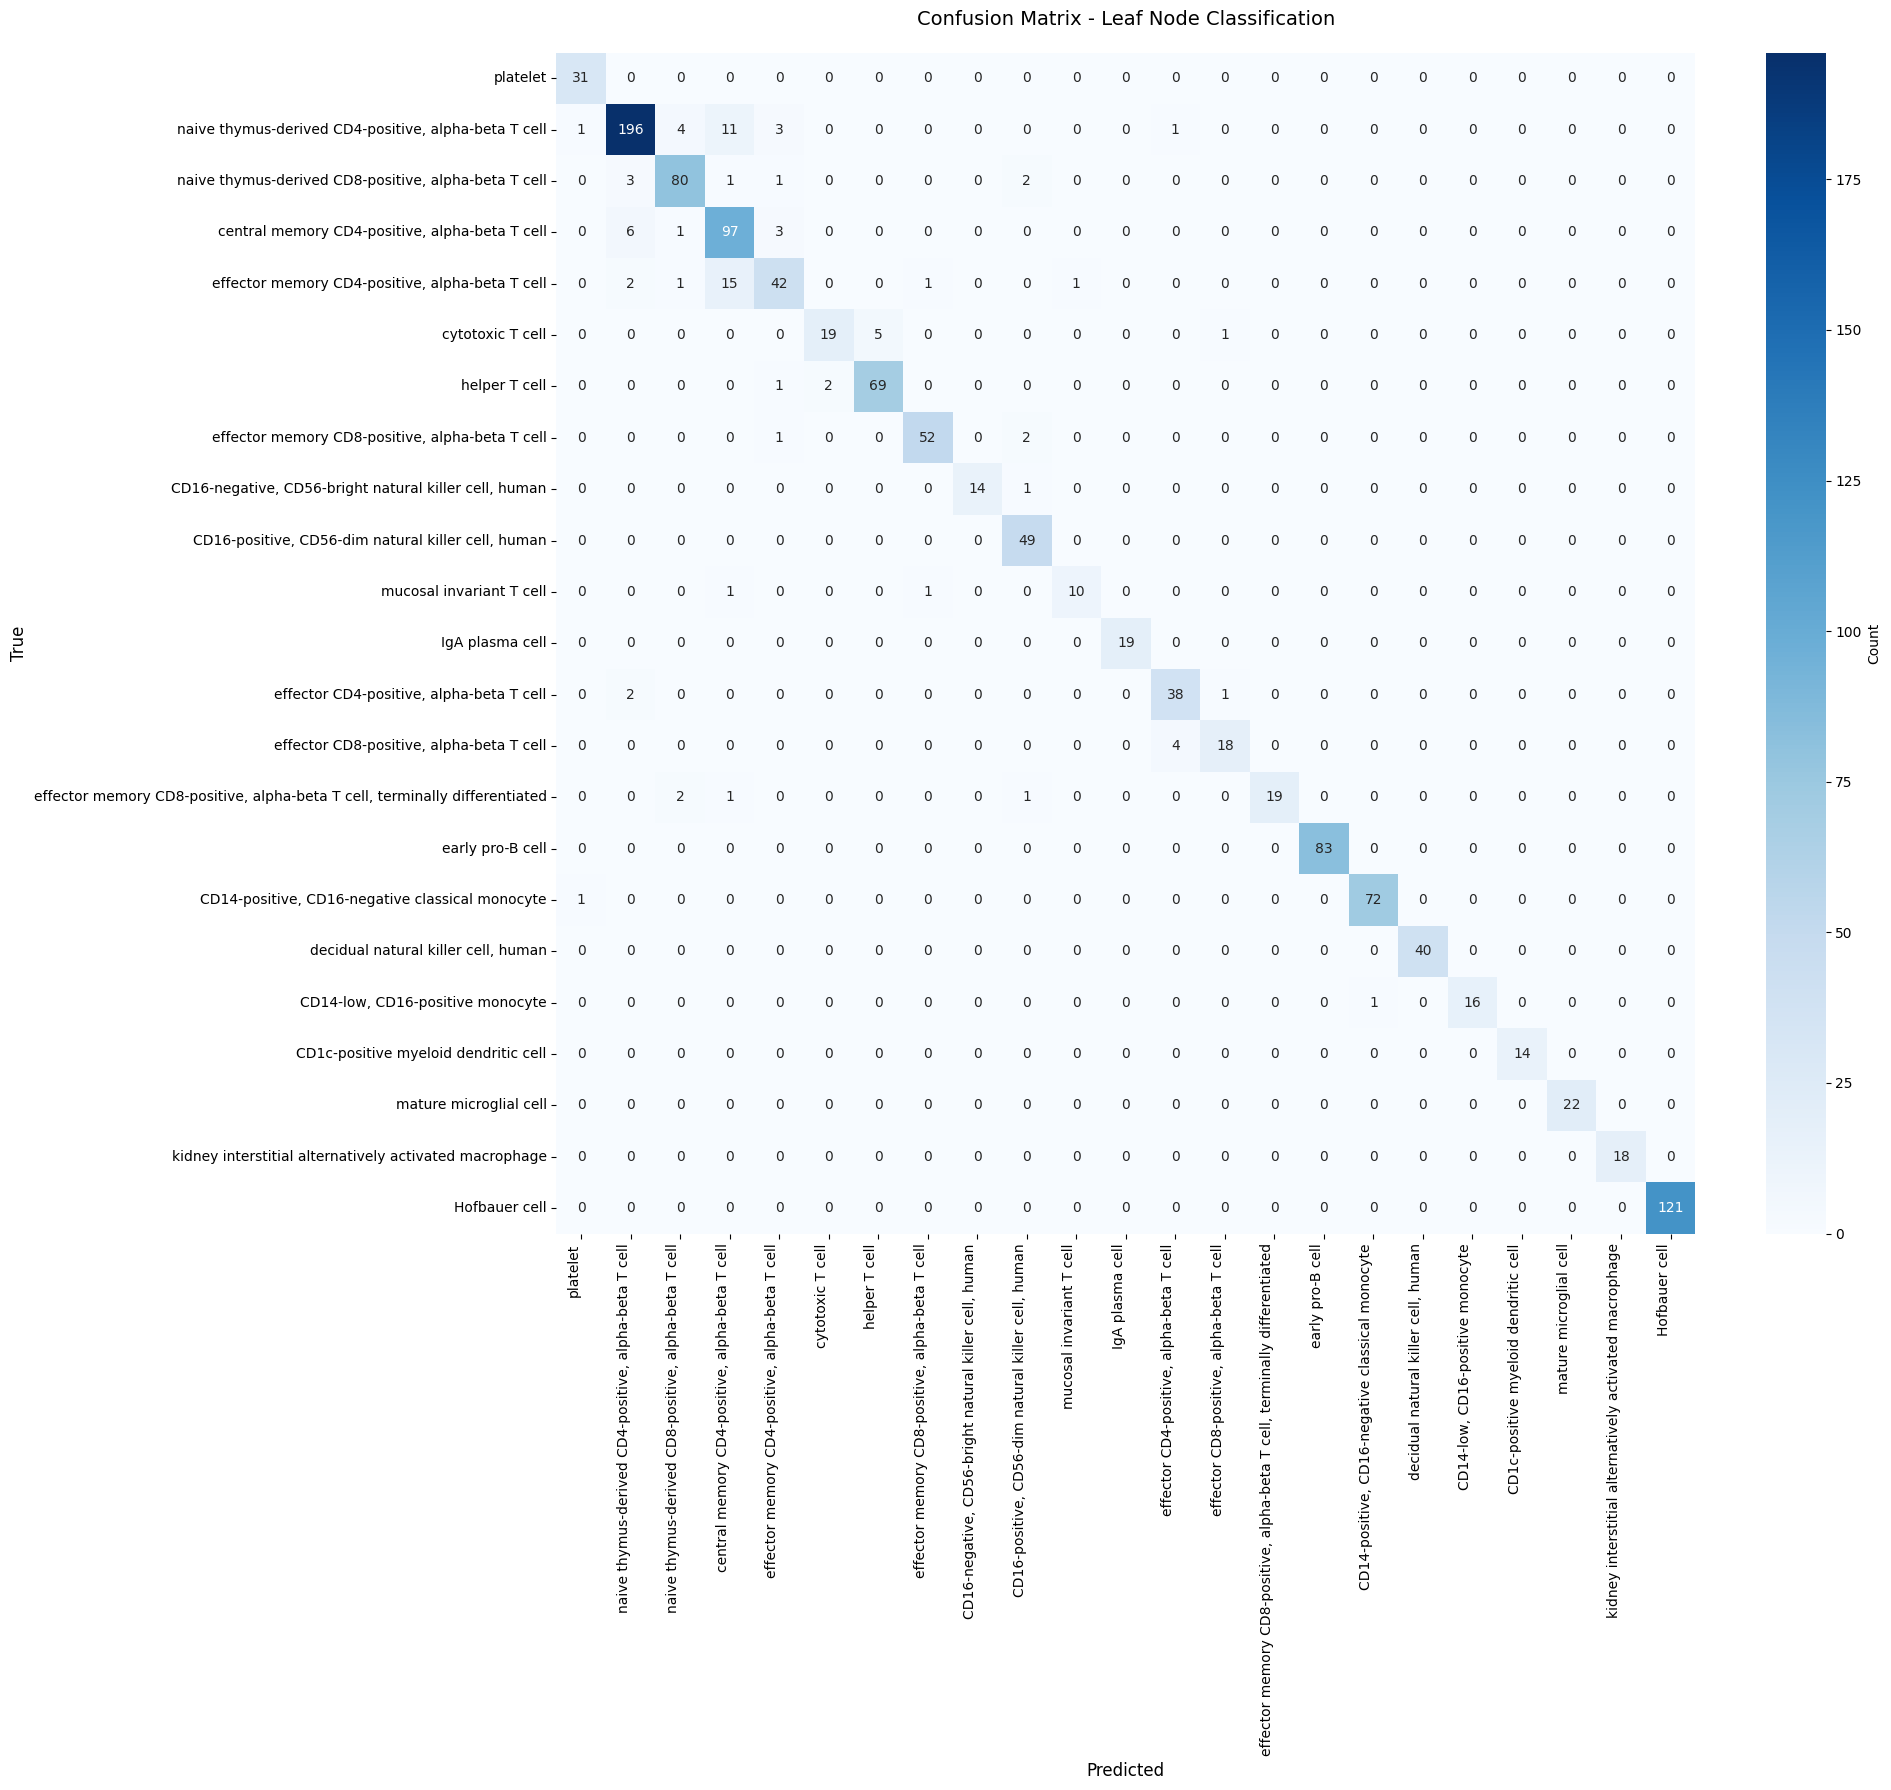

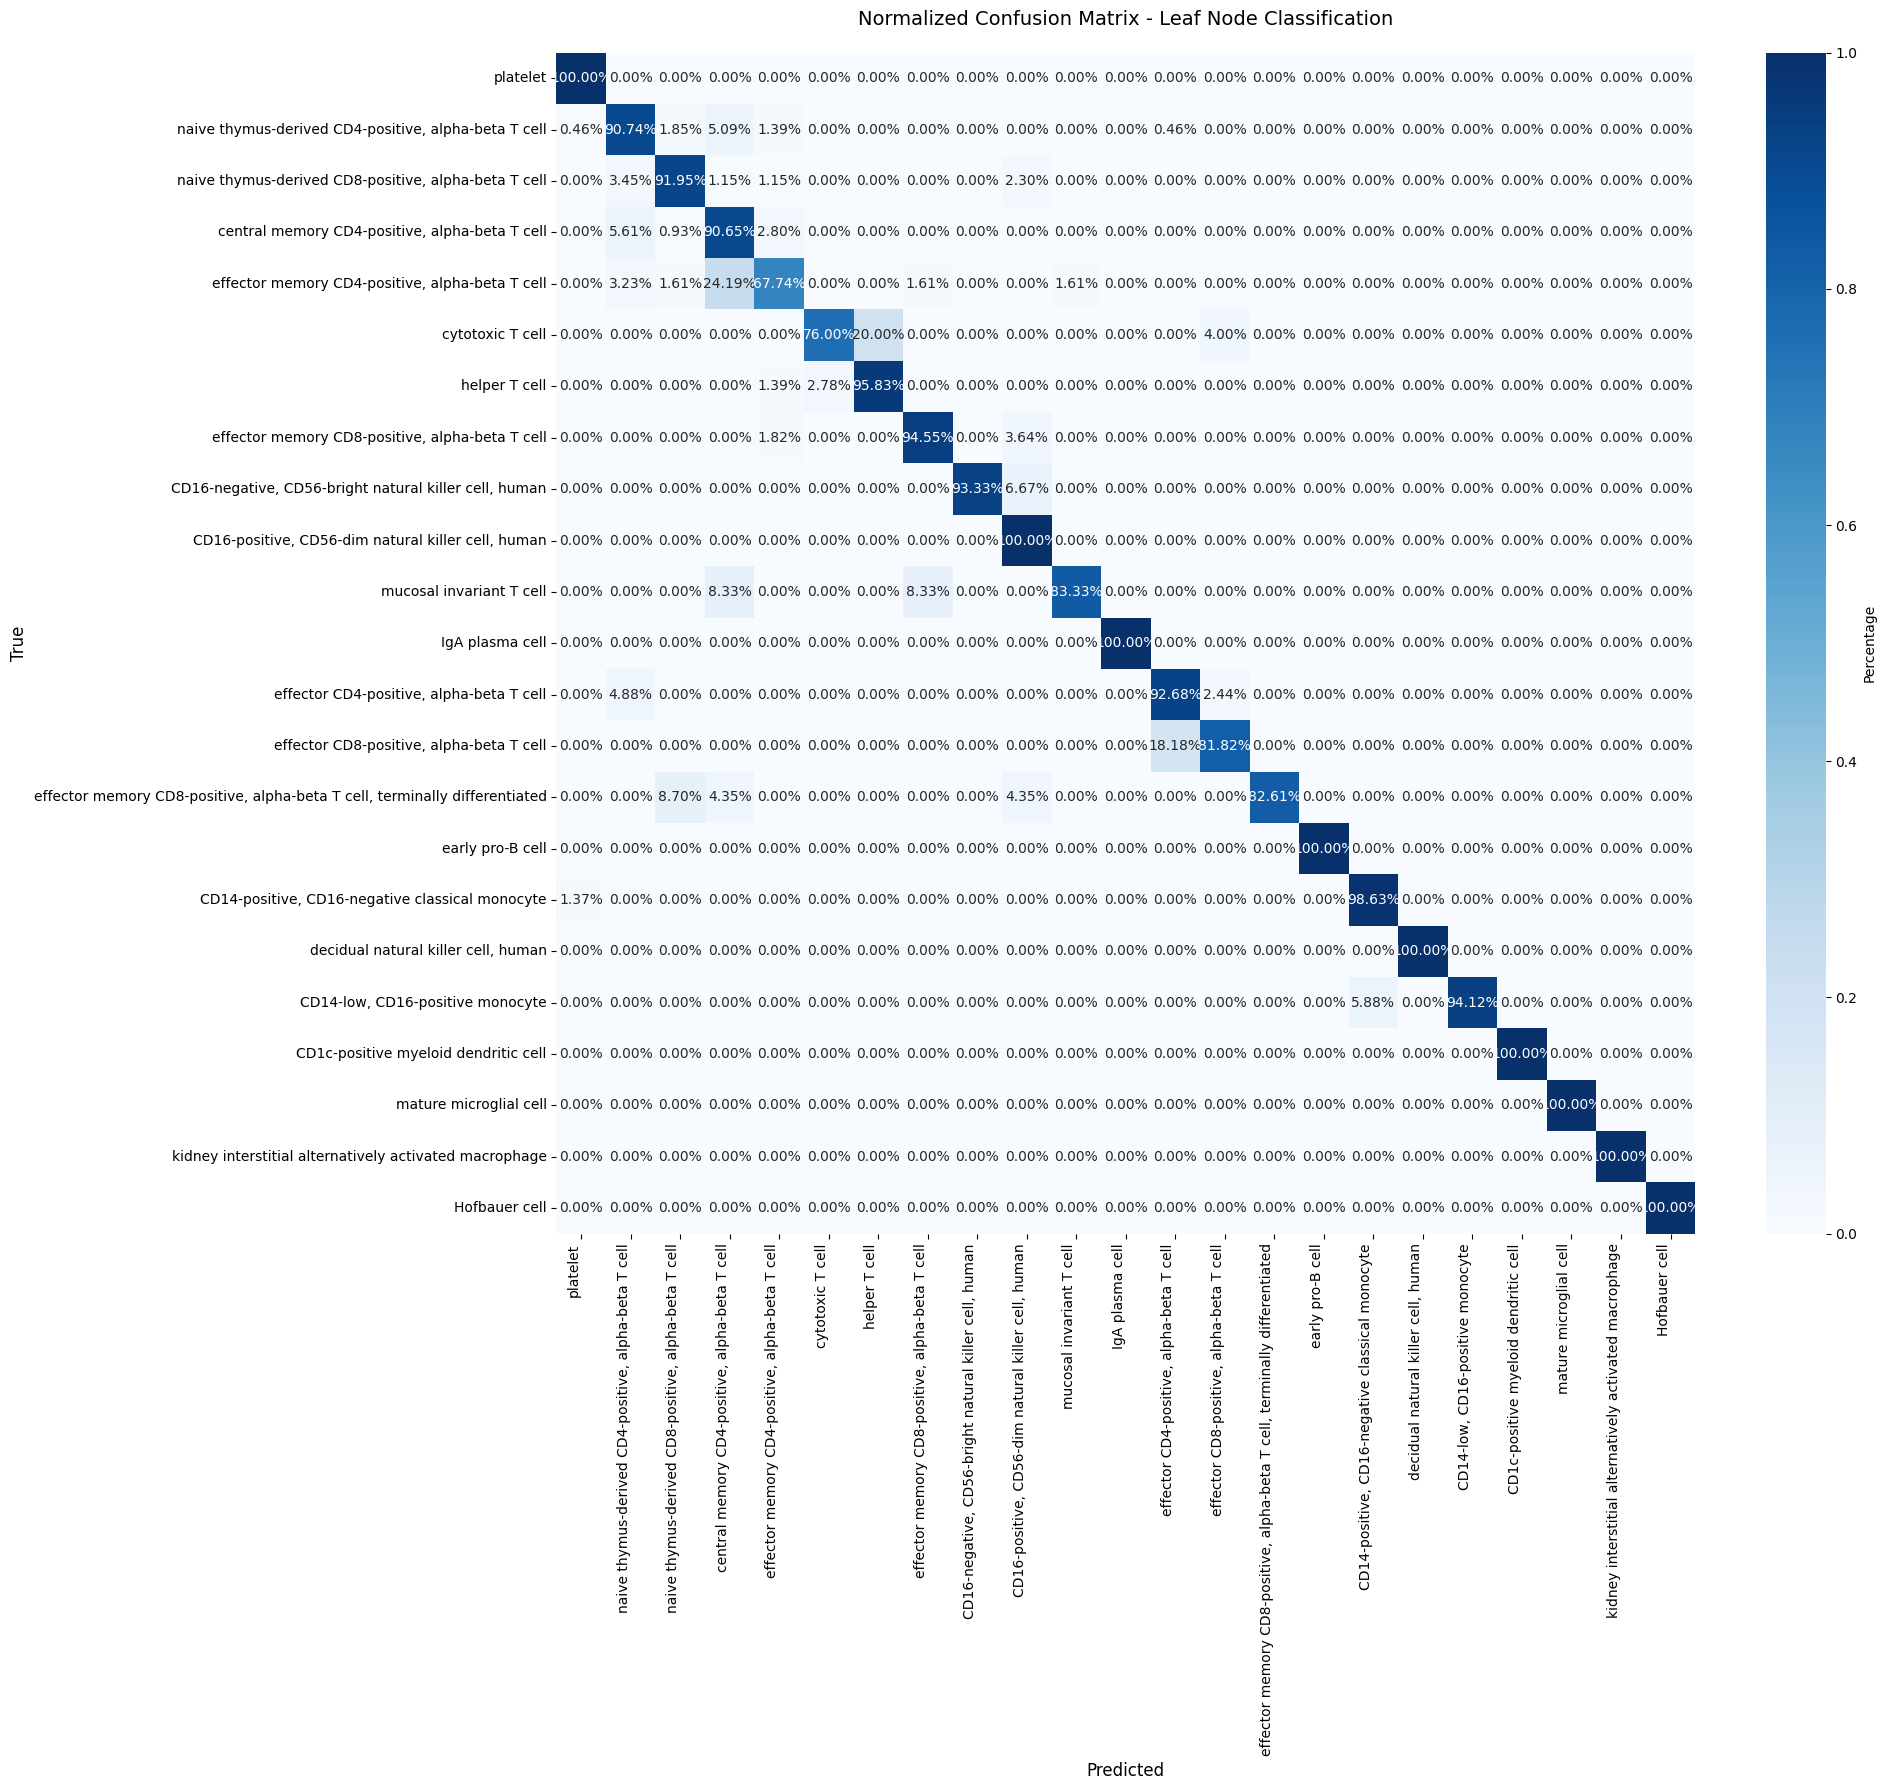

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Get cell type names for labels
unique_labels_sorted = sorted(unique_labels)
label_names = [cl[reverse_mapping[idx]].name for idx in unique_labels_sorted]

# Plot confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Leaf Node Classification', fontsize=14, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(20, 18))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Percentage'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Normalized Confusion Matrix - Leaf Node Classification', fontsize=14, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Training History

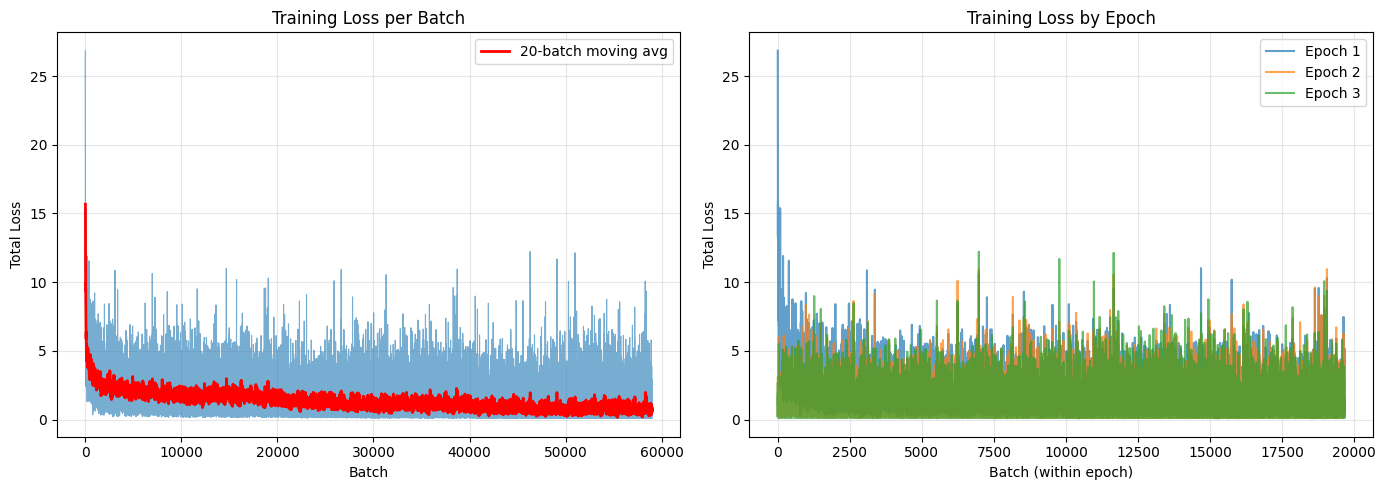


Training Summary:
  Initial loss: 26.8449
  Final loss: 0.5783
  Loss reduction: 97.8%


In [10]:
# Plot training loss from checkpoint
batch_loss_history = checkpoint['batch_loss_history']
num_epochs = checkpoint['epoch']
batches_per_epoch = len(batch_loss_history) // num_epochs

plt.figure(figsize=(14, 5))

# Overall training loss
plt.subplot(1, 2, 1)
plt.plot(batch_loss_history, alpha=0.6, linewidth=0.8)
plt.xlabel('Batch')
plt.ylabel('Total Loss')
plt.title('Training Loss per Batch')
plt.grid(True, alpha=0.3)

# Moving average
window_size = 20
if len(batch_loss_history) >= window_size:
    moving_avg = np.convolve(batch_loss_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size-1, len(batch_loss_history)), moving_avg, 
             color='red', linewidth=2, label=f'{window_size}-batch moving avg')
    plt.legend()

# Loss by epoch
plt.subplot(1, 2, 2)
if num_epochs > 1:
    epoch_losses = [batch_loss_history[i*batches_per_epoch:(i+1)*batches_per_epoch] 
                   for i in range(num_epochs)]
    for i, losses in enumerate(epoch_losses):
        plt.plot(losses, label=f'Epoch {i+1}', alpha=0.7)
    plt.xlabel('Batch (within epoch)')
    plt.ylabel('Total Loss')
    plt.title('Training Loss by Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"  Initial loss: {batch_loss_history[0]:.4f}")
print(f"  Final loss: {batch_loss_history[-1]:.4f}")
print(f"  Loss reduction: {(1 - batch_loss_history[-1]/batch_loss_history[0])*100:.1f}%")

## 9. Top Misclassifications

In [11]:
# Find most common misclassifications
print("\n" + "="*80)
print("TOP 10 MISCLASSIFICATIONS")
print("="*80)

misclassifications = []
for true_label, pred_label in zip(all_labels, all_predictions):
    if true_label != pred_label:
        misclassifications.append((true_label, pred_label))

misclass_counts = Counter(misclassifications)

print(f"\nTotal misclassifications: {len(misclassifications):,} / {len(all_labels):,} ({len(misclassifications)/len(all_labels)*100:.2f}%)")
print(f"\nTop 10 most common mistakes:")
print(f"{'True Cell Type':<40} {'→':<3} {'Predicted Cell Type':<40} {'Count':<8}")
print("-" * 100)

for (true_idx, pred_idx), count in misclass_counts.most_common(10):
    true_name = cl[reverse_mapping[true_idx]].name
    pred_name = cl[reverse_mapping[pred_idx]].name
    print(f"{true_name:<40} {'→':<3} {pred_name:<40} {count:<8}")

print("="*80 + "\n")


TOP 10 MISCLASSIFICATIONS

Total misclassifications: 85 / 1,224 (6.94%)

Top 10 most common mistakes:
True Cell Type                           →   Predicted Cell Type                      Count   
----------------------------------------------------------------------------------------------------
effector memory CD4-positive, alpha-beta T cell →   central memory CD4-positive, alpha-beta T cell 15      
naive thymus-derived CD4-positive, alpha-beta T cell →   central memory CD4-positive, alpha-beta T cell 11      
central memory CD4-positive, alpha-beta T cell →   naive thymus-derived CD4-positive, alpha-beta T cell 6       
cytotoxic T cell                         →   helper T cell                            5       
naive thymus-derived CD4-positive, alpha-beta T cell →   naive thymus-derived CD8-positive, alpha-beta T cell 4       
effector CD8-positive, alpha-beta T cell →   effector CD4-positive, alpha-beta T cell 4       
naive thymus-derived CD8-positive, alpha-beta T cell →   n

## 10. Summary Report

## 11. F1 Score Analysis (Leaf Nodes)

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

print("\n" + "="*80)
print("F1 SCORE ANALYSIS (LEAF NODES)")
print("="*80)

# Calculate different F1 averaging methods
micro_f1 = f1_score(all_labels, all_predictions, average='micro')
macro_f1 = f1_score(all_labels, all_predictions, average='macro')
weighted_f1 = f1_score(all_labels, all_predictions, average='weighted')

# Per-class F1, Precision, Recall
per_class_f1 = f1_score(all_labels, all_predictions, average=None)
per_class_precision = precision_score(all_labels, all_predictions, average=None, zero_division=0)
per_class_recall = recall_score(all_labels, all_predictions, average=None, zero_division=0)

print(f"\n{'Metric':<20} {'Value':<10} {'Relationship to Accuracy'}")
print("-" * 80)
print(f"{'Accuracy':<20} {accuracy*100:>6.2f}%   (baseline)")
print(f"{'Micro-F1':<20} {micro_f1*100:>6.2f}%   ← Should EQUAL accuracy!")
print(f"{'Macro-F1':<20} {macro_f1*100:>6.2f}%   ← Equal weight to all classes")
print(f"{'Weighted-F1':<20} {weighted_f1*100:>6.2f}%   ← Weighted by class frequency")

print(f"\n{'Verification:':<20}")
print(f"  Micro-F1 == Accuracy? {np.isclose(micro_f1, accuracy)}")
if macro_f1 > accuracy:
    print(f"  Macro-F1 > Accuracy? {macro_f1 > accuracy} (rare classes perform BETTER!)")
else:
    print(f"  Macro-F1 <= Accuracy? {macro_f1 <= accuracy} (rare classes perform worse)")

print("\n" + "="*80)
print("PER-CLASS F1 SCORES (LEAF NODES)")
print("="*80)
print(f"{'Cell Type':<50} {'Count':<8} {'Precision':<12} {'Recall':<10} {'F1 Score':<10}")
print("-" * 110)

# Sort by F1 score (descending)
class_metrics = []
for i, label_idx in enumerate(sorted(unique_labels)):
    cl_id = reverse_mapping[label_idx]
    cell_name = cl[cl_id].name
    count = (all_labels == label_idx).sum()
    
    class_metrics.append({
        'name': cell_name,
        'count': count,
        'precision': per_class_precision[i],
        'recall': per_class_recall[i],
        'f1': per_class_f1[i]
    })

# Sort by F1 score
class_metrics_sorted = sorted(class_metrics, key=lambda x: x['f1'], reverse=True)

for m in class_metrics_sorted:
    print(f"{m['name']:<50} {m['count']:<8} {m['precision']*100:>6.2f}%      {m['recall']*100:>6.2f}%    {m['f1']*100:>6.2f}%")

print("="*80)

# Show relationship between accuracy and F1
print("\n" + "="*80)
if macro_f1 > accuracy:
    print("WHY MACRO-F1 IS HIGHER THAN ACCURACY (Good News!)")
    print("="*80)
    print("\nMacro-F1 gives EQUAL weight to each class (rare classes matter as much as common).")
    print("Accuracy gives MORE weight to common classes (they dominate the overall metric).")
    print("\nIn this case, RARE classes perform BETTER than common classes!")
    print("This means your model does NOT overfit to common classes.\n")
    print("Largest classes with below-average performance:")
    print(f"{'Cell Type':<50} {'Count':<8} {'F1':<10} {'Weight in Accuracy':<20}")
    print("-" * 100)
    
    # Find large classes with F1 below macro average
    large_underperformers = [m for m in class_metrics if m['count'] > 50 and m['f1'] < macro_f1]
    large_underperformers_sorted = sorted(large_underperformers, key=lambda x: x['count'], reverse=True)
    for m in large_underperformers_sorted:
        weight_in_acc = m['count'] / len(all_labels) * 100
        print(f"{m['name']:<50} {m['count']:<8} {m['f1']*100:>6.2f}%    {weight_in_acc:>6.2f}% of samples")
else:
    print("WHY MACRO-F1 IS LOWER THAN ACCURACY")
    print("="*80)
    print("\nMacro-F1 gives EQUAL weight to each class (rare classes matter as much as common).")
    print("Accuracy gives MORE weight to common classes (they dominate the overall metric).")
    print("\nClasses pulling Macro-F1 down (rare + low performance):")
    print(f"{'Cell Type':<50} {'Count':<8} {'F1':<10} {'Weight in Accuracy':<20}")
    print("-" * 100)
    
    # Find worst performers
    worst_classes = sorted(class_metrics, key=lambda x: x['f1'])[:5]
    for m in worst_classes:
        weight_in_acc = m['count'] / len(all_labels) * 100
        print(f"{m['name']:<50} {m['count']:<8} {m['f1']*100:>6.2f}%    {weight_in_acc:>6.2f}% of samples")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"✓ Micro-F1 ({micro_f1*100:.2f}%) = Accuracy ({accuracy*100:.2f}%) → As expected!")
if macro_f1 > accuracy:
    print(f"✓ Macro-F1 ({macro_f1*100:.2f}%) > Accuracy ({accuracy*100:.2f}%) → EXCELLENT! Rare classes perform well!")
    print(f"✓ Weighted-F1 ({weighted_f1*100:.2f}%) ≈ Accuracy → Weighted by class size")
    print("\nConclusion: Macro-F1 provides an UPPER BOUND on performance.")
    print("           Your model performs BETTER on rare cell types than common ones.")
    print("           Common T-cell subtypes (CD4+ memory variants) are transcriptionally similar,")
    print("           making them harder to distinguish. Rare cell types (platelets, plasma cells)")
    print("           have distinctive gene expression signatures and are easier to classify.")
else:
    print(f"✓ Macro-F1 ({macro_f1*100:.2f}%) < Accuracy ({accuracy*100:.2f}%) → Rare classes pull it down")
    print(f"✓ Weighted-F1 ({weighted_f1*100:.2f}%) ≈ Accuracy → Weighted by class size")
    print("\nConclusion: Macro-F1 provides a LOWER BOUND on performance when classes are imbalanced.")
    print("           It reveals that rare cell types perform worse than overall accuracy suggests.")
print("="*80 + "\n")

In [ ]:
print("\n" + "="*80)
print("INTERNAL NODE ACCURACY ANALYSIS")
print("="*80)
print("\nEvaluating cells whose ground truth label is an INTERNAL node")
print("(Not the leaf-labeled cells, but cells labeled with internal nodes)")
print("\nProcessing ENTIRE validation set (all batches)")

# Set threshold
THRESHOLD = 0.5
print(f"Using threshold: {THRESHOLD}\n")

# ============================================================================
# Re-run validation to collect INTERNAL-labeled samples this time
# ============================================================================

print("=" * 80)
print("RE-RUNNING VALIDATION FOR INTERNAL-LABELED SAMPLES")
print("=" * 80)

# Identify which indices in mapping_dict are internal nodes
internal_indices_set = {mapping_dict[cid] for cid in internal_values}

# Storage for results
all_internal_outputs = []  # model logits
all_internal_labels = []   # ground truth internal node indices

with torch.no_grad():
    for i, (X_batch, obs_batch) in enumerate(val_dataloader):
        # Data preparation
        X_batch = torch.from_numpy(X_batch).float()
        X_batch = torch.log1p(X_batch)
        X_batch = X_batch.to(device)

        label_strings = obs_batch["cell_type_ontology_term_id"]
        y_batch = torch.tensor([mapping_dict[term] for term in label_strings],
                              device=device, dtype=torch.long)

        # FILTER: Keep only INTERNAL node labels this time
        is_internal = torch.tensor([y.item() in internal_indices_set for y in y_batch], 
                                   device=device)

        if is_internal.sum() == 0:
            continue  # Skip batches with no internal samples

        X_batch_internal = X_batch[is_internal]
        y_batch_internal = y_batch[is_internal]

        # Forward pass to get logits
        outputs = validation_model(X_batch_internal)
        
        # Store results
        all_internal_outputs.append(outputs.cpu())
        all_internal_labels.extend(y_batch_internal.cpu().numpy())

# Concatenate all outputs
all_internal_outputs = torch.cat(all_internal_outputs, dim=0)
all_internal_labels = np.array(all_internal_labels)

print(f"\nCollected {len(all_internal_labels):,} internal-labeled samples")
print(f"Model output shape: {all_internal_outputs.shape} (samples, leaf_classes)")

# ============================================================================
# Step 1: Convert logits to probabilities (softmax)
# ============================================================================

# Apply softmax to get leaf probabilities
leaf_probs = torch.softmax(all_internal_outputs, dim=1)
print(f"Leaf probabilities shape: {leaf_probs.shape}")

# ============================================================================
# Step 2: Marginalize to get internal node probabilities
# ============================================================================

# Create marginalization tensor (internal_nodes x leaf_nodes)
marginalization_tensor = torch.FloatTensor(
    marginalization_df.loc[internal_values, leaf_values].values
)
print(f"Marginalization tensor: {marginalization_tensor.shape} (internal × leaf)")

# Marginalize: sum leaf probs to get internal probs
internal_probs = torch.matmul(leaf_probs, marginalization_tensor.T)
print(f"Internal probabilities shape: {internal_probs.shape} (samples, internal_nodes)")

# ============================================================================
# Step 3: Filter out nodes with no leaf descendants (cannot be evaluated)
# ============================================================================

print("\n" + "=" * 80)
print("FILTERING NON-EVALUABLE INTERNAL NODES")
print("=" * 80)

# Find internal nodes with at least one leaf descendant
valid_internal_nodes = []
for cl_id in internal_values:
    if cl_id in marginalization_df.index:
        row_sum = marginalization_df.loc[cl_id, leaf_values].sum()
        if row_sum > 0:
            valid_internal_nodes.append(cl_id)

print(f"Internal nodes WITH leaf descendants: {len(valid_internal_nodes)} / {len(internal_values)}")
print(f"Internal nodes WITHOUT leaf descendants: {len(internal_values) - len(valid_internal_nodes)}")

# Create mapping for valid internal nodes only
valid_internal_indices_set = {mapping_dict[cid] for cid in valid_internal_nodes}

# Re-filter our collected samples
valid_mask = np.array([label in valid_internal_indices_set for label in all_internal_labels])
valid_internal_labels = all_internal_labels[valid_mask]
valid_internal_probs = internal_probs[valid_mask]

print(f"\nEvaluable samples: {len(valid_internal_labels):,} / {len(all_internal_labels):,}")
print(f"Removed: {len(all_internal_labels) - len(valid_internal_labels):,} samples with non-evaluable labels")

# ============================================================================
# Step 4: Calculate accuracy for valid internal nodes
# ============================================================================

internal_idx_to_position = {mapping_dict[cid]: i for i, cid in enumerate(internal_values)}

correct_predictions = 0
total_samples = len(valid_internal_labels)

for sample_idx, true_internal_idx in enumerate(valid_internal_labels):
    internal_position = internal_idx_to_position[true_internal_idx]
    pred_prob = valid_internal_probs[sample_idx, internal_position].item()
    
    if pred_prob >= THRESHOLD:
        correct_predictions += 1

accuracy_internal = correct_predictions / total_samples if total_samples > 0 else 0

print("\n" + "=" * 80)
print("RESULTS")
print("=" * 80)
print(f"Evaluable internal-labeled samples: {total_samples:,}")
print(f"Correct predictions (P >= {THRESHOLD}): {correct_predictions:,}")
print(f"Internal node accuracy: {accuracy_internal*100:.2f}%")

# ============================================================================
# Step 5: Per-class accuracy for evaluable internal nodes
# ============================================================================

print("\n" + "=" * 80)
print("PER-INTERNAL-NODE ACCURACY (Only evaluable nodes)")
print("=" * 80)
print(f"{'Internal Node':<50} {'Count':<10} {'Accuracy':<10}")
print("-" * 80)

from collections import defaultdict
per_node_stats = defaultdict(lambda: {'correct': 0, 'total': 0})

for sample_idx, true_internal_idx in enumerate(valid_internal_labels):
    internal_position = internal_idx_to_position[true_internal_idx]
    pred_prob = valid_internal_probs[sample_idx, internal_position].item()
    
    per_node_stats[true_internal_idx]['total'] += 1
    if pred_prob >= THRESHOLD:
        per_node_stats[true_internal_idx]['correct'] += 1

# Create reverse mapping
reverse_mapping = {v: k for k, v in mapping_dict.items()}

# Sort by accuracy
node_accuracies = []
for internal_idx, stats in per_node_stats.items():
    cl_id = reverse_mapping[internal_idx]
    cell_name = cl[cl_id].name
    accuracy = stats['correct'] / stats['total'] if stats['total'] > 0 else 0
    node_accuracies.append((cell_name, stats['total'], accuracy))

node_accuracies.sort(key=lambda x: x[2], reverse=True)

for cell_name, count, acc in node_accuracies:
    print(f"{cell_name:<50} {count:<10} {acc*100:>6.2f}%")

print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Leaf node accuracy (from earlier):      93.06% (expected to change after full run)")
print(f"Internal node accuracy (evaluable):      {accuracy_internal*100:.2f}%")
print(f"")
print(f"Evaluable internal nodes:                {len(per_node_stats)} / {len(internal_values)}")
print(f"Samples evaluated:                       {total_samples:,} / {len(all_internal_labels):,}")
print(f"Threshold used:                          {THRESHOLD}")
print("=" * 80 + "\n")